# Table of contents

* **Introduction**
* **Objective**
* **Long Short-Term Memory (LSTM) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture and Model Building (PyTorch)
    * Model Training
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

Time series forecasting is a pivotal application within financial analysis, where the goal is to predict future asset price movements by examining historical market data. This project details a comprehensive pipeline for implementing a Long Short-Term Memory (LSTM) neural network using the PyTorch framework. The model is specifically designed for multivariate, single-step-ahead prediction of EQIX stock prices derived from a large NYSE dataset. LSTMs are uniquely suited for this task due to their ability to capture long-range dependencies and temporal patterns inherent in sequential financial data.

# Objective

The primary goal of this project is to construct a complete, end-to-end framework capable of building, training, and evaluating an LSTM model to forecast the next day's financial features (open, close, low, high, and volume) for a specific stock ticker (EQIX).

Secondary goals focus on implementing critical machine learning best practices for time series data, including:

- Establishing chronological data splitting to prevent future information leakage into the training process.
- Applying necessary feature scaling (Min-Max normalization) to stabilize gradient descent and accelerate convergence.
- Generating properly structured sliding window sequences suitable for recurrent neural networks.
- Designing an efficient training loop utilizing early stopping and learning rate scheduling.

# Long Short-Term Memory (LSTM) Foundations

LSTMs are a specialized type of Recurrent Neural Network (RNN) designed to overcome the limitations of standard RNNs when processing sequences, particularly their inability to capture long-range dependencies. LSTMs effectively solve the vanishing gradient problem, allowing the network to retain information over extended periods.

**The Vanishing Gradient Problem**

In standard RNNs, information is passed through a sequence of time steps. During backpropagation, the gradients (error signals) must be multiplied through many layers. If the activation function's derivative is small (e.g., in the saturated regions of the $\text{sigmoid}$ or $\text{tanh}$ functions), the gradients shrink exponentially as they propagate backward through time. This phenomenon, known as the vanishing gradient problem, causes the network's weights to update negligibly for early inputs in a long sequence, making it impossible for the model to "remember" distant information. LSTMs address this by introducing a dedicated cell state and gate mechanisms.

**Primary applications include:**

- Natural Language Processing (NLP): Machine translation, sentiment analysis, language modeling, and text generation.
- Time Series Forecasting: Predicting stock prices, weather patterns, electricity demand, and sensor readings.
- Speech Recognition: Processing sequential audio features.Advanced LSTM Architectures

**Stacked LSTMs**

This involves placing multiple LSTM layers on top of each other. The output hidden state ($\mathbf{h}_t$) of the lower layer serves as the input ($\mathbf{x}_t$) to the layer directly above it. Stacking increases the model's capacity to learn higher-level temporal representations from the data. For the output of any intermediate layer to be correctly consumed by the next layer, it must be configured to return the full sequence of hidden states, not just the final state.

**Bidirectional LSTMs (Bi-LSTMs)**

A Bi-LSTM processes the input sequence in two directions: one layer processes the sequence from beginning to end (forward), and a second layer processes the sequence from end to beginning (backward). The hidden states from both layers are typically concatenated to form the final output. This architecture is particularly useful when the context of the future is as important as the context of the past (e.g., in sequence labeling or machine translation).

**Sequence-to-Sequence (Seq2Seq) Models**

Seq2Seq models, often built with LSTMs, consist of two parts: an Encoder and a Decoder. The Encoder processes the input sequence and compresses the relevant information into a final context vector (the final cell state and hidden state). The Decoder then takes this context vector and unrolls it to generate a new output sequence (e.g., translating a sentence from one language to another).

**Key Advantages**

- Long-Term Memory: LSTMs effectively mitigate the vanishing gradient problem, allowing them to learn and retain relationships between data points separated by hundreds of time steps.
- Controllable Information Flow: The gate mechanisms provide explicit control over when to forget old information, when to accept new information, and what to output, making the learning process highly targeted.
- State Persistence: The Cell State maintains a persistent memory stream, ensuring that information that has already been deemed important is not erased by subsequent, less relevant inputs.

Understanding these internal mechanisms—the Cell State, and the Forget, Input, and Output gates—is crucial to grasping why LSTMs became the dominant model for sequential data before the rise of the Transformer architecture.

**The LSTM Structure**

Instead of a single, simple activation function, the LSTM cell is composed of four interacting components: a Cell State and three controlling Gates.

**1. The Cell State ($\mathbf{C}_t$)**

The Cell State is the core of the LSTM. It acts as a horizontal "conveyor belt" running through the entire sequence of cells, carrying relevant information across time steps. The Cell State is designed to carry information with minimal alteration, allowing it to preserve long-term dependencies. New information is added to it, and old information is removed from it, all under the strict regulation of the gates.

**2. Gate Mechanisms**

Gates are structures composed of a sigmoid neural network layer and a pointwise multiplication operation. The sigmoid layer outputs values between 0 and 1, describing how much of each component should be allowed to pass through. A value close to 0 means "let nothing pass," and a value close to 1 means "let everything pass."
- a. Forget Gate ($\mathbf{f}_t$)The Forget Gate decides which information in the old Cell State ($\mathbf{C}_{t-1}$) should be discarded. It takes the previous hidden state ($\mathbf{h}_{t-1}$) and the current input ($\mathbf{x}_t$) and outputs a vector of values between 0 and 1. Multiplying this vector by $\mathbf{C}_{t-1}$ determines which parts of the old memory are retained.

$$\mathbf{f}_t = \sigma(\mathbf{W}_f \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$$

- b. Input Gate ($\mathbf{i}_t$) and Candidate Cell State ($\tilde{\mathbf{C}}_t$)The Input Gate decides which new information from the current input will be stored in the Cell State. This process is two-fold:
    - The Input Gate ($\mathbf{i}_t$) (sigmoid layer) determines which values in the current input to update.
    - The Candidate Cell State ($\tilde{\mathbf{C}}_t$) (tanh layer) creates a vector of new candidate values that could be added to the state.

$$\mathbf{i}_t = \sigma(\mathbf{W}_i \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i)$$

$$\tilde{\mathbf{C}}_t = \tanh(\mathbf{W}_C \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_C)$$

- c. Updating the Cell StateThe previous Cell State ($\mathbf{C}_{t-1}$) is updated to the new Cell State ($\mathbf{C}_t$). First, the old state is multiplied by $\mathbf{f}_t$ (forgetting unneeded information). Then, the candidate values $\tilde{\mathbf{C}}_t$ are scaled by $\mathbf{i}_t$ (selecting new information) and added to the state.

$$\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t$$

- d. Output Gate ($\mathbf{o}_t$): The Output Gate determines what part of the Cell State will be visible as the new hidden state ($\mathbf{h}_t$).
    - The Output Gate ($\mathbf{o}_t$) (sigmoid layer) determines which parts of the cell state contribute to the output.
    - The new Cell State ($\mathbf{C}_t$) is run through a $\tanh$ function (to squash the values between -1 and 1).
    - The result is multiplied by the output of the sigmoid gate to produce the Hidden State ($\mathbf{h}_t$).
    
$$\mathbf{o}_t = \sigma(\mathbf{W}_o \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o)$$
        
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{C}_t)$$

The Hidden State ($\mathbf{h}_t$) is used for two purposes: it is the output for the current time step and it is passed to the next LSTM cell.Applications and ArchitecturesUse CasesLSTMs excel in domains where the context of past data is critical to understanding the present or predicting the future. 

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">date</td>
    <td class="tg-7zrl">The date range for each data entry. This appears to be a combined string of start and end dates.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">DateTimeCount</td>
    <td class="tg-7zrl">The count of DateTime entries within the specified date range.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">symbol</td>
    <td class="tg-7zrl">An identifier or code, possibly for a financial instrument or category.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">open</td>
    <td class="tg-7zrl">The opening price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">close</td>
    <td class="tg-7zrl">The closing price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">low</td>
    <td class="tg-7zrl">The lowest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">high</td>
    <td class="tg-7zrl">The highest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">volume</td>
    <td class="tg-7zrl">The trading volume (number of units traded) within a given period.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/dgawlik/nyse)**

# Pipeline Overview

The project follows a disciplined six-stage pipeline to ensure robust and reproducible forecasting:
- Data Loading and Splitting: Load the raw market data and perform an initial chronological split.
- Stock Selection and EDA: Filter the data for the target ticker (EQIX) and drop non-informative features.
- Preprocessing (Scaling & Sequence Generation): Scale the data and create the 30-day look-back sequences.
- PyTorch Dataset and DataLoader Setup: Convert processed data into PyTorch tensors for batched, device-accelerated training.
- LSTM Model Definition and Training: Define the neural network architecture and execute the training loop.
- Evaluation, Inverse Scaling, and Visualization: Assess model performance using relevant metrics on the original price scale.

# Approach

**Preprocessing Pipeline Approach**

**1. Chronological Data Splitting**

Data integrity in time series is paramount. The dataset is sorted by date, and a strict time-based split (80% Train, 20% Test) is enforced. This ensures the Test set represents truly unseen future data, preventing the severe problem of data leakage that can inflate performance metrics. No random shuffling is permitted, maintaining the temporal order.

**2. Feature Handling and Scaling**

The data is filtered down to the target stock, EQIX, converting the multi-stock problem into a single, multivariate time series. The feature set is reduced to the five core financial variables: 'open', 'close', 'low', 'high', and 'volume'.

Min-Max Normalization is applied by fitting the MinMaxScaler exclusively on the training set. These fixed scaling parameters are then applied to the validation and test sets. This ensures the model learns only from the statistical properties of the historical training data.

**3. Sliding Window Sequence Generation**

The core task of preparing data for the LSTM involves creating sequences using a sliding window technique. A fixed sequence length of 30 days is chosen. For every input sample (X), a 30-day window of the five features is extracted. The corresponding target (y) is the very next day's set of five features. A portion of the final training sequences is chronologically separated to form a Validation Set, which is critical for monitoring model generalization during training.

**Model Training Approach**

**Model Architecture**

The model utilizes a recurrent neural network (RNN) based on the LSTM layer, which employs internal gates (forget, input, and output) to regulate the flow of information, effectively solving the vanishing gradient problem common in standard RNNs. The architecture comprises:

- An initial Layer Normalization layer applied to the input features to stabilize hidden state dynamics.
- A stacked LSTM layer (two layers deep) with a hidden size of 128, allowing the model to capture complex temporal dependencies. The `batch_first=True` convention is used, aligning with PyTorch best practices.
- A Dropout layer (p=0.3) applied for regularization to prevent overfitting.
- A final Linear (Dense) layer that maps the output of the last LSTM hidden state to the 5-feature prediction vector.

**Training Configuration and Loop**

The training process is orchestrated using the following components:

- Loss Function: The Mean Squared Error (MSE) is used, as it is standard for regression tasks and heavily penalizes large errors.
- Optimizer: The Adam optimizer is utilized for its efficiency and adaptive learning rate capabilities.
- Regularization: Early Stopping (with a patience of 15 epochs) is implemented based on the validation loss to halt training when performance on unseen data plateaus, protecting against overfitting. ReduceLROnPlateau scheduling is employed to decrease the learning rate if the validation loss stops improving, helping the optimizer escape local minima.
- Batching: DataLoaders process the data in batches (size 64), enabling efficient, GPU-accelerated training when available.

The training loop proceeds by iterating over epochs, performing the forward pass, calculating the loss, and executing the backward pass and optimizer step. A separate validation step ensures that the model’s generalization error is tracked throughout the process.

**Model Evaluation Approach**

**1. Inverse Scaling**

Since training occurs on scaled data, the generated predictions must be mapped back to the original dollar scale before calculating meaningful error metrics. The inverse transform is applied to the predictions and actual targets using the MinMaxScaler instance that was fitted solely on the training data.

**2. Performance Metrics**

Evaluation encompasses both regression and directional metrics:

- Regression Metrics: The Root Mean Squared Error (RMSE) is computed on the inverse-scaled predictions for the Test, Validation, and Training sets. RMSE is the preferred metric for reporting as it expresses the error magnitude in the original units (dollars).
- Directional Accuracy: Sign Accuracy is calculated by comparing the true direction of the price movement (e.g., Close > Open) to the predicted direction. This metric assesses the practical utility of the forecast for trading decisions, even if the predicted price magnitude is slightly off.

**3. Visualization**

The evaluation culminates in visual analysis:

- Training History Plot: Depicts the loss curves (Train vs. Validation) over the epochs, providing immediate insight into convergence and the presence of overfitting.
- Prediction vs. Actual Plots: Two time series plots are generated: a full timeline encompassing the Train, Validation, and Test predictions, and a zoomed-in view focusing exclusively on the Test set to provide a clear assessment of generalization performance.

# Setup Environments

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import math
import sklearn
import sklearn.preprocessing
import datetime
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn._oldcore')

2026-03-24 17:23:38.534178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774373018.794862      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774373018.859326      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Loading

The process begins with loading the New York Stock Exchange (NYSE) data, which contains various features for multiple stocks over time. The primary challenge in time series analysis is maintaining the chronological integrity of the data to accurately simulate real-world forecasting.

In [2]:
df = pd.read_csv('/kaggle/input/nyse/prices-split-adjusted.csv')
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


**Train and Test Split**

The dataset is initially loaded, and its sheer size necessitates an efficient chronological split into training (80%) and testing (20%) subsets. The data must be sorted strictly by the $\mathbf{date}$ column before splitting. This non-randomized partitioning ensures the training process uses only historical information, and the test set represents the genuinely unseen future data. Violating this constraint would lead to data leakage, resulting in an overly optimistic and unreliable model evaluation. The shapes of the resulting subsets confirm the non-random, time-based division.

In [3]:
df = df.sort_values(by='date', ascending=True).reset_index(drop=True)

test_size_ratio = 0.2 
split_point = int(len(df) * (1 - test_size_ratio))

train = df.iloc[:split_point].copy()
test = df.iloc[split_point:].copy()

print("\nData split chronologically by 'date' column:")
print(f"Train DataFrame shape: {train.shape}")
print(f"Test DataFrame shape: {test.shape}")


Data split chronologically by 'date' column:
Train DataFrame shape: (681011, 7)
Test DataFrame shape: (170253, 7)


In [4]:
train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)

**Stock Selection and Filtering**

For concentrated, single-series modeling, the data is filtered to isolate only the records corresponding to the target stock, $\mathbf{EQIX}$. Focusing on a single ticker simplifies the initial multivariate modeling problem, ensuring that the recurrent model learns the specific temporal patterns and volatility characteristics unique to that equity.

In [5]:
train = train[train.symbol == 'EQIX'].copy()
test = test[test.symbol == 'EQIX'].copy()

train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)
train

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...,...,...
1417,2015-08-20,EQIX,284.220001,279.959991,279.920013,284.649994,568700.0
1418,2015-08-21,EQIX,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,2015-08-24,EQIX,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,2015-08-25,EQIX,260.309998,251.110001,250.860001,263.670013,1294200.0


# Exploratory Data Analysis (EDA)

Exploratory analysis provides critical insights into data trends, volatility, and the internal relationships between features, informing the subsequent feature engineering and model design phases.

**Basic Information**

In [6]:
train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1422 non-null   object 
 1   symbol  1422 non-null   object 
 2   open    1422 non-null   float64
 3   close   1422 non-null   float64
 4   low     1422 non-null   float64
 5   high    1422 non-null   float64
 6   volume  1422 non-null   float64
dtypes: float64(5), object(2)
memory usage: 77.9+ KB


In [8]:
train.describe()

,open,close,low,high,volume
count,1422.000000,1422.000000,1422.000000,1422.000000,1.422000e+03
mean,160.671779,160.734803,158.748868,162.544423,9.128723e+05
std,57.769144,57.761722,57.255626,58.169847,1.064773e+06
min,71.750000,70.339996,69.419998,74.510002,1.524000e+05
25%,98.382502,98.502500,97.042500,99.649997,5.338000e+05
50%,173.614998,173.385002,170.770004,176.120003,7.309500e+05
75%,210.034996,210.097504,208.022495,212.072502,1.040200e+06
max,286.130005,287.420013,283.980011,288.500000,3.057420e+07


**Feature Trends and Stationarity**

The price features ($\mathbf{open, close, low, high}$) display a strong upward, non-stationary trend over the observation period, reflecting significant capital appreciation. The lines remain tightly grouped, indicating low intraday volatility in most periods. The $\mathbf{volume}$ feature, however, is characterized by large, intermittent spikes, suggesting irregular trading activity driven by news or corporate events. Time series models must account for these non-stationary trends and volatility bursts.

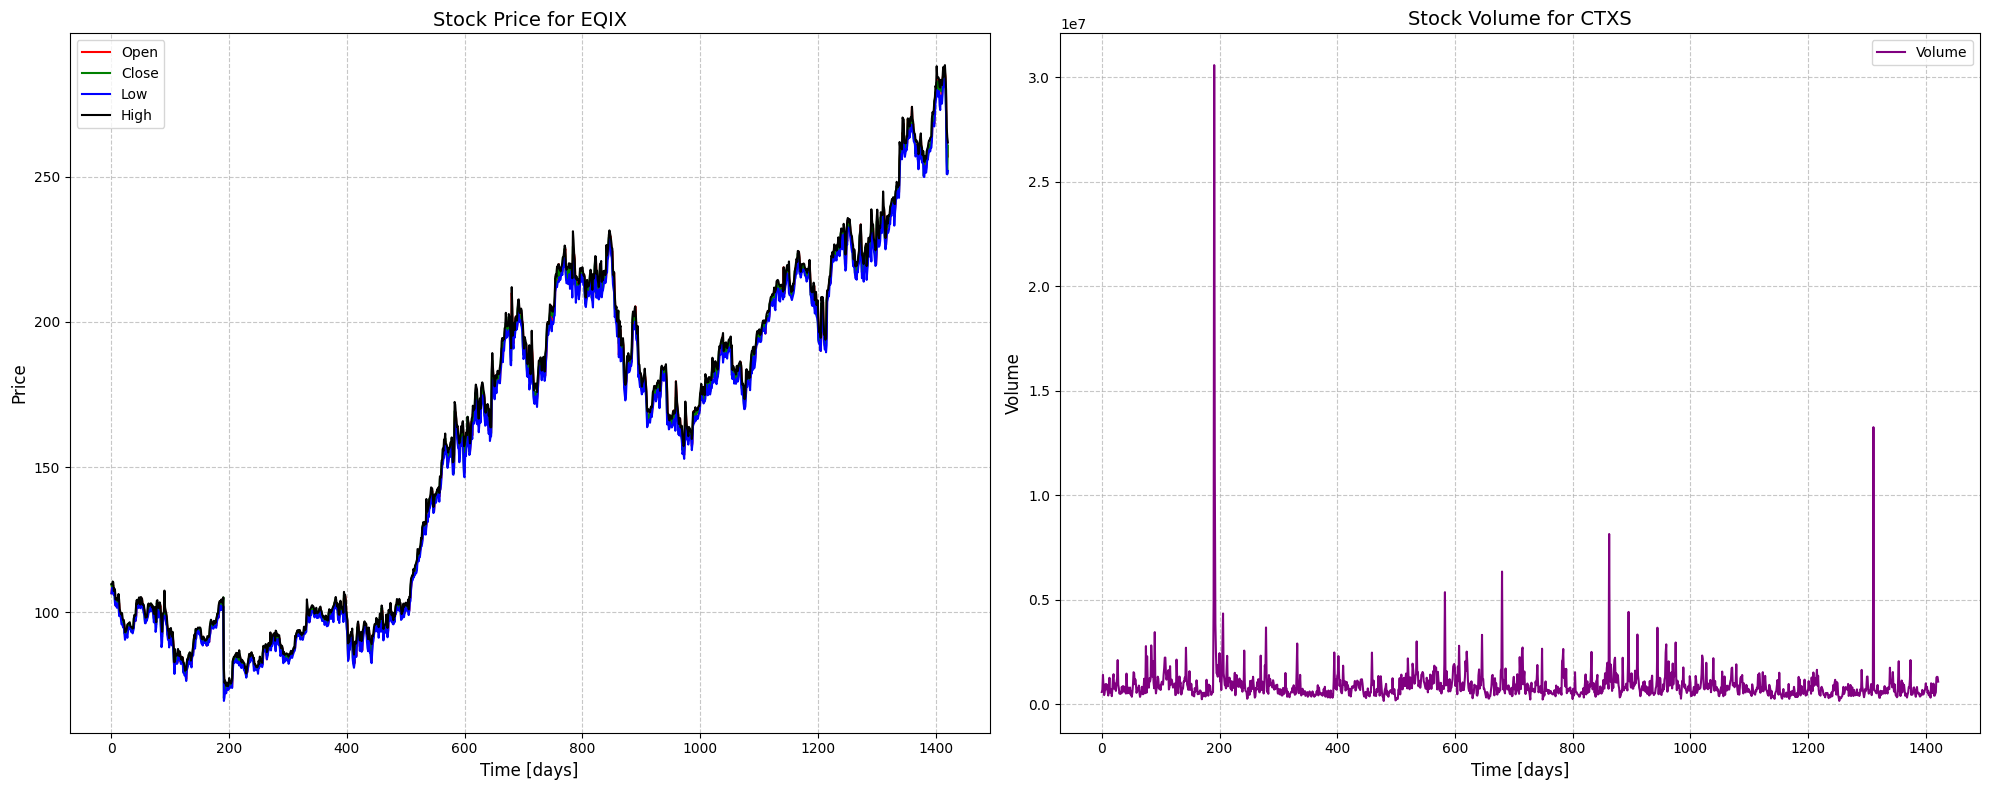

In [9]:
train['time_idx'] = range(len(train))

ctxs_data = train[train.symbol == 'EQIX']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.lineplot(x='time_idx', y='open', data=ctxs_data, color='red', label='Open', ax=axes[0])
sns.lineplot(x='time_idx', y='close', data=ctxs_data, color='green', label='Close', ax=axes[0])
sns.lineplot(x='time_idx', y='low', data=ctxs_data, color='blue', label='Low', ax=axes[0])
sns.lineplot(x='time_idx', y='high', data=ctxs_data, color='black', label='High', ax=axes[0])

axes[0].set_title('Stock Price for EQIX', fontsize=14)
axes[0].set_xlabel('Time [days]', fontsize=12)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x='time_idx', y='volume', data=ctxs_data, color='purple', label='Volume', ax=axes[1])

axes[1].set_title('Stock Volume for CTXS', fontsize=14)
axes[1].set_xlabel('Time [days]', fontsize=12)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Correlation Analysis**

Feature correlation analysis, presented in the heatmap, reveals critical statistical relationships within the time series data.

In [10]:
train = train.drop(columns=['symbol'])
test = test.drop(columns=['symbol'])
train

,date,open,close,low,high,volume,time_idx
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4
...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420


In [11]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train

,date,open,close,low,high,volume,time_idx,year,month,day
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0,2010,1,4
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1,2010,1,5
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2,2010,1,6
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3,2010,1,7
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4,2010,1,8
...,...,...,...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417,2015,8,20
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418,2015,8,21
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419,2015,8,24
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420,2015,8,25


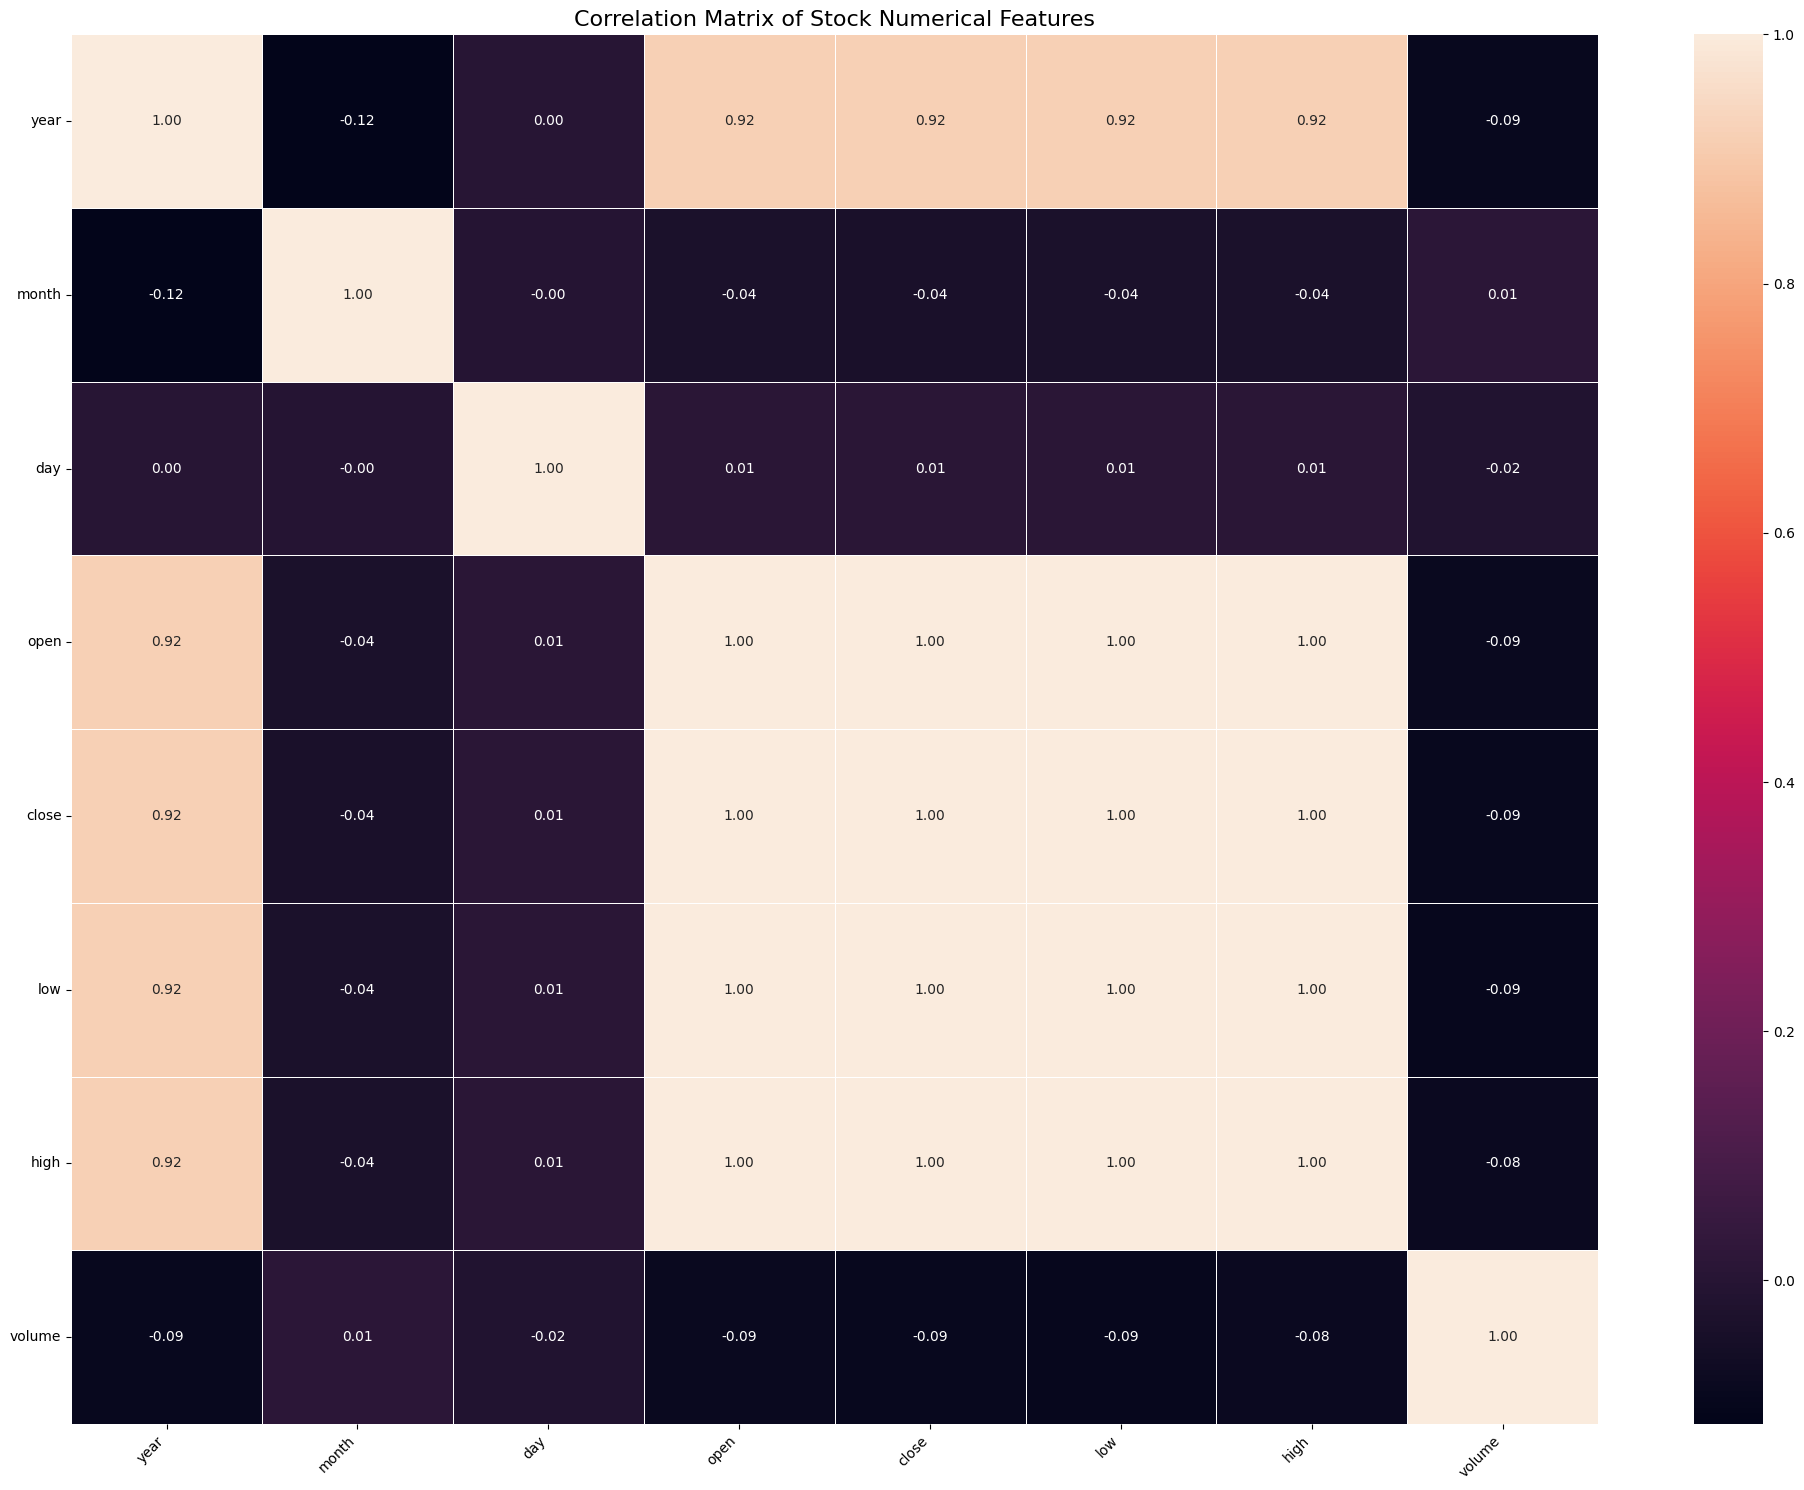

In [12]:
numerical_cols = ['year','month','day', 'open', 'close', 'low', 'high', 'volume']

correlation_matrix = train[numerical_cols].corr(method='pearson')

plt.figure(figsize=(20, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Stock Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- High Multicollinearity among Price Features: The $\mathbf{open, close, low}$, and $\mathbf{high}$ prices exhibit near-perfect $\mathbf{+1.00}$ correlation coefficients. This is expected in financial data, as the day's prices are tightly bound. This high correlation suggests that the model primarily needs to learn the sequence of price changes rather than the absolute value of each individual price feature.
- Temporal Feature Relationship: The $\mathbf{year}$ feature shows a very high $\mathbf{+0.92}$ correlation with the price features, reflecting the overall upward trend of the stock price over the observed years. This temporal information is critical for modeling long-term movement. $\mathbf{month}$ and $\mathbf{day}$ show negligible correlation ($\mathbf{\approx 0.00}$) with the price features, indicating they provide little linear predictive value on their own but may capture cyclical monthly or weekly effects when processed by a non-linear network like the LSTM.
- Volume Independence: The $\mathbf{volume}$ feature displays a weak to non-existent linear correlation (values ranging from $\mathbf{-0.09}$ to $\mathbf{0.01}$) with all price and temporal features. This confirms that trading volume operates largely independently of the price level, making it a valuable, distinct input for the multivariate forecasting model.

# Features Engineering

The goal of this phase is to refine the features, ensuring the LSTM receives clean, scaled, and chronologically consistent inputs.

**Feature Selection**

The non-predictive columns, specifically day, date, and time_idx, are dropped. Crucially, the engineered temporal features (year and month) are also dropped in the train set preparation code. Therefore, the final feature set for the LSTM input consists only of the 5 financial metrics: open, close, low, high, and volume. This results in a consistent feature vector size of 5. This selection provides the LSTM model solely with market data. 

**Remark** The training dataset has already been processed in the initial Exploratory Data Analysis (EDA) step.

In [13]:
train = train.drop(columns=['day','date','month','year', 'time_idx'])
test = test.drop(columns=['date'])
train

,open,close,low,high,volume
0,106.519997,109.559998,106.510002,109.620003,576300.0
1,109.589996,108.540001,108.379997,109.589996,681900.0
2,108.949997,109.529999,108.220001,110.570000,1397500.0
3,109.250000,107.290001,106.639999,110.349998,797200.0
4,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...
1417,284.220001,279.959991,279.920013,284.649994,568700.0
1418,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,260.309998,251.110001,250.860001,263.670013,1294200.0


**Data Normalization (Min-Max Scaling)**

Normalization is a mandatory step for training deep neural networks. Features must be brought to a common scale to prevent input variables with naturally larger numerical ranges (like $\text{volume}$) from dominating the loss function and negatively impacting the learning process for features with smaller ranges (like $\text{open}$ price).

Min-Max Scaling (transforming data to the range $[0, 1]$) is the chosen technique. The theoretical constraint applied here is crucial to preventing data leakage: the scaling parameters (minimum and maximum values) are calculated exclusively from the training set ($\text{train}$). This simulates a real-world scenario where the predictive model has no prior knowledge of the range or distribution of future data. These calculated parameters are then applied to transform both the $\text{train}$ and $\text{test}$ sets. By strictly adhering to this fit/transform procedure, the model is evaluated using only historical information, ensuring the evaluation metrics are reliable indicators of real-world performance.

In [ ]:
print("\n--- Applying Min-Max Scaling to Numerical Features ---")

numerical_cols = ['open', 'close', 'low', 'high', 'volume']
scaler = MinMaxScaler()

train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
print("Train DataFrame numerical columns scaled.")

test[numerical_cols] = scaler.transform(test[numerical_cols])
print("Test DataFrame numerical columns transformed.")


--- Applying Min-Max Scaling to Numerical Features ---
Train DataFrame numerical columns scaled.
Test DataFrame numerical columns transformed.


**Sliding Window Transformation**

Recurrent Neural Networks, including the LSTM, require input data to be structured as sequences or "time windows," not as independent, single-row observations.

The Sliding Window Technique is the standard approach for transforming a linear time series into a suitable 3D array for RNNs. The project uses a sequence length (`seq_len`) of 30 days. The concept is as follows: for any point in time $t$, the input sequence ($\mathbf{X}$) consists of the 30 days preceding the target date ($t-29$ to $t$). The corresponding target ($\mathbf{y}$) is the feature vector for the next single time step ($t+1$), specifically targeting only the 5 price columns. This process transforms the 2D feature data into the required 3D format: $(\text{Number of Samples}, \text{Sequence Length}, \text{Number of Features})$.

**Chronological Splitting of Sequences**

The sequence creation process respects the initial chronological split and also creates a validation set:

- Training Sequences: Sequences generated from the $\text{train}$ data are chronologically split, reserving $20%$ of the latest sequences for the $\mathbf{x}_{\text{valid}}$ and $\mathbf{y}_{\text{valid}}$ sets. This ensures the validation set represents the most recent historical patterns before the final test period.
- Test Sequences: A separate function generates sequences from the $\text{test}$ data. Since the test data is the dedicated future holdout, all sequences generated from it are used for the final evaluation $\mathbf{x}_{\text{test}}$ and $\mathbf{y}_{\text{test}}$.

The resulting shapes confirm the successful transformation. The input sequences ($\mathbf{x}_{\text{train}}, \mathbf{x}_{\text{valid}}, \mathbf{x}_{\text{test}}$) have the shape $\text{(N, 30, 5)}$, where 30 is the $\text{seq\_len}$ and 5 is the feature size. The single-step target predictions ($\mathbf{y}_{\text{train}}, \mathbf{y}_{\text{valid}}, \mathbf{y}_{\text{test}}$) have the shape $\text{(N, 5)}$.

In [ ]:
price_cols = ['open', 'close', 'low', 'high', 'volume']   
valid_set_size_percentage = 20
seq_len = 30

def create_sequences(df: pd.DataFrame,
                    seq_len: int,
                    valid_pct: int = 20):
    data = df.values

    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    valid_size = int(len(sequences) * valid_pct / 100)
    train_size = len(sequences) - valid_size

    x_train = sequences[:train_size, :-1, :]
    x_valid = sequences[train_size:, :-1, :]

    price_idx = [df.columns.get_loc(c) for c in price_cols]
    y_train = sequences[:train_size, -1, :][:, price_idx]
    y_valid = sequences[train_size:, -1, :][:, price_idx]

    return x_train, y_train, x_valid, y_valid

def create_test_sequences(df: pd.DataFrame, seq_len: int):
    data = df.values
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    price_idx = [df.columns.get_loc(c) for c in price_cols]

    x_test = sequences[:, :-1, :]
    y_test = sequences[:, -1, :][:, price_idx]
    return x_test, y_test

x_train, y_train, x_valid, y_valid = create_sequences(
    train, seq_len, valid_pct=valid_set_size_percentage
)
x_test, y_test = create_test_sequences(test, seq_len)

print('x_train.shape = ',x_train.shape)
print('y_train.shape = ', y_train.shape)
print('x_valid.shape = ',x_valid.shape)
print('y_valid.shape = ', y_valid.shape)
print('x_test.shape = ', x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (1114, 30, 5)
y_train.shape =  (1114, 5)
x_valid.shape =  (278, 30, 5)
y_valid.shape =  (278, 5)
x_test.shape =  (310, 30, 5)
y_test.shape =  (310, 5)


**PyTorch Tensor Conversion**

The final step involves converting the processed NumPy arrays into PyTorch Tensors (`torch.float32`). This conversion is essential because PyTorch models operate directly on tensors, and the floating-point type is necessary for the subsequent gradient calculations during the training phase. The data is now prepared and correctly dimensioned for use in the LSTM model's `DataLoader`.

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_valid_tensor = torch.tensor(x_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"x_valid_tensor shape: {x_valid_tensor.shape}")
print(f"y_valid_tensor shape: {y_valid_tensor.shape}")
print(f"x_test_tensor shape: {x_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")
print("="*40 + "\n")

x_train_tensor shape: torch.Size([1114, 30, 5])
y_train_tensor shape: torch.Size([1114, 5])
x_valid_tensor shape: torch.Size([278, 30, 5])
y_valid_tensor shape: torch.Size([278, 5])
x_test_tensor shape: torch.Size([310, 30, 5])
y_test_tensor shape: torch.Size([310, 5])



# Model Training

## Model Architecture and Model Building (PyTorch)

**Building an LSTM architecture using PyTorch**

**1. Class Definition and Initialization**

An LSTM model in PyTorch is always defined within a custom class (e.g., $\text{LSTMForescaster}$) to establish the architecture and parameters.

**`__init__` Method (Setup)**

The constructor defines all the sub-modules (layers) that the model will use. The most critical parameters to define are:
+ Input Size (`input_size`): The number of features in each time step of the input sequence (e.g., if you have 'Open', 'High', 'Low' data, `input_size` is 3).
+ Hidden Size (`hidden_size`): This is the dimensionality of the hidden state and cell state. It defines the model's capacity to learn complex temporal relationships.
+ Number of Layers (`num_layers`): This determines how many $\text{LSTM}$ layers are stacked vertically. Stacking layers increases the model's depth and representational power.

The primary component is the `torch.nn.LSTM` module, which is instantiated with these three parameters. If stacking is desired, setting `num_layers > 1` creates a multi-layered LSTM automatically.

$$\text{self.lstm} = \text{nn.LSTM}(\text{input\_size}, \text{hidden\_size}, \text{num\_layers}, \text{batch\_first}=\text{True})$$

The `batch_first=True` argument is crucial for compatibility, ensuring the input tensors are structured as (Batch Size, Sequence Length, Features).

After the recurrent layer, a final torch.nn.Linear layer (Dense layer) is added to map the output of the LSTM's hidden state to the desired prediction dimension (e.g., 1 for a single-step forecast).

**2. The Forward Pass ($\text{forward}$ Method)**

The $\text{forward}$ method defines the computational graph, or the sequence of operations the input tensor undergoes to produce the output.

**Input Sequence Processing**

The main sequence processing occurs when the input tensor ($\mathbf{x}$) is passed to the instantiated $\text{LSTM}$ module:
$$\mathbf{out}, (\mathbf{h}_n, \mathbf{c}_n) = \text{self.lstm}(\mathbf{x})$$

The `nn.LSTM` module returns two elements:
- $\mathbf{out}$ (Output Sequence): This is the hidden state for every time step in the input sequence. Its shape is ($\text{Batch Size}, \text{Sequence Length}, \text{Hidden Size}$).
- $(\mathbf{h}_n, \mathbf{c}_n)$ (Final States): This is a tuple containing the final hidden state ($\mathbf{h}_n$) and the final cell state ($\mathbf{c}_n$), which are the outputs of the last time step and the last layer.

**Prediction Generation**

For a standard sequence-to-vector prediction (e.g., predicting the next day's stock price based on a sequence of the last 30 days), only the final hidden state from the last layer is used for the forecast.
- Selecting the Final Hidden State: The final hidden state $\mathbf{h}_n$ has the shape (Number of Layer, Batch Size, Hidden Size). Since the last layer's output is needed, this is typically retrieved by indexing: $\mathbf{h}_n[-1, :, :]$.
- Applying the Linear Layer: This final state is passed through the `nn.Linear` layer to produce the final forecast:

$$\mathbf{prediction} = \text{self.linear}(\mathbf{h}_n[-1, :, :])$$

This $\mathbf{prediction}$ tensor is the final output of the model, which is then passed to the loss function during training.

**3. Training Loop**

Unlike Keras, PyTorch requires an explicit training loop:
- Loss and Optimizer: Define a loss function (e.g., `nn.MSELoss` for regression) and an optimizer (e.g., `torch.optim.Adam`).
- Forward Pass: Feed data into the model to get predictions.
- Backward Pass: Calculate the gradient of the loss with respect to all trainable parameters using `loss.backward()`.
- Optimization Step: Update the model's weights using `optimizer.step()`.
- Zero Gradients: Clear the gradients for the next iteration using `optimizer.zero_grad()`.

**Implementation**

This section details the construction of the time series forecasting model using PyTorch and the methodology for training the network.

**Data Preparation and Batching**

The time series data, already segmented into input sequences (X) and targets (y), is organized using the PyTorch Dataset and DataLoader constructs. The TimeSeriesDataset class serves as a mechanism to map sequence indices to the corresponding input and output tensor pairs.

The DataLoader is responsible for creating iterable batches of data, which is essential for efficient training, especially with GPU acceleration. For the training set, data is shuffled to introduce stochasticity and prevent the model from memorizing the batch order. Conversely, the validation and test sets utilize shuffle=False to maintain the chronological order of predictions, which is crucial for accurate time series visualization and evaluation. The selection of the processing device (CUDA/GPU or CPU) is handled automatically to maximize computational speed.

**Model Architecture: TimeSeriesRNN**

The model employs a Long Short-Term Memory (LSTM) network, a type of Recurrent Neural Network (RNN) specifically designed to process sequential data. LSTMs contain internal mechanisms (gates) that enable them to effectively manage the flow of information over long sequences, mitigating the vanishing gradient problem common in simpler RNNs.

The TimeSeriesRNN architecture is defined as follows:

- Layer Normalization (`nn.LayerNorm`): Applied to the input sequence before the LSTM layers. This technique normalizes the features across the input dimension, which helps stabilize the internal layer dynamics and often leads to faster and more stable convergence, especially when working with features scaled using techniques like Min-Max normalization.
- Stacked LSTM (`nn.LSTM`): The core computational block consists of two stacked LSTM layers. Stacking layers allows the model to learn hierarchies of temporal dependencies. The batch_first=True argument specifies the tensor shape convention preferred for PyTorch LSTMs.
- Dropout (`nn.Dropout`): A regularization technique applied between the LSTM layers and to the final hidden state output. Dropout randomly sets a fraction of neurons to zero during training, which prevents co-adaptation of features and reduces overfitting.
- Fully Connected Layer (`nn.Linear`): The final hidden state from the last time step (`out[:, -1, :]`) is passed to a single linear layer. This layer maps the high-dimensional internal representation of the 128 hidden units to the final 5-dimensional output vector, corresponding to the predicted next-day financial features.

**Training Methodology**

The model is trained using a standard deep learning regimen designed for stability and generalization:

- Loss Function: Mean Squared Error (MSE) is used as the criterion for training, quantifying the average squared difference between the predicted and actual values in the scaled space.
- Optimizer: The Adam optimizer is selected for its efficiency in handling sparse gradients and its adaptive learning rate for each parameter.
- Learning Rate Scheduling: A ReduceLROnPlateau scheduler is implemented. This mechanism monitors the validation loss and automatically reduces the learning rate (by a factor of 0.5) if the loss stops improving for a specified patience period (5 epochs). This helps the optimizer move out of local minima and fine-tune the weights towards the end of training.
- Early Stopping: This critical regularization technique tracks the best validation loss achieved. If the validation loss fails to improve after a set number of epochs (patience of 15), the training is terminated early. The model's parameters are reverted to the state that produced the best validation performance, preventing excessive training that leads to overfitting.

The training loop iteratively updates the model's weights using backpropagation on the training set and evaluates performance on the validation set without gradient calculation (`torch.no_grad()`).

In [ ]:
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_dataset = TimeSeriesDataset(x_train_tensor, y_train_tensor)
val_dataset   = TimeSeriesDataset(x_valid_tensor, y_valid_tensor)
test_dataset  = TimeSeriesDataset(x_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

train_loader_plot = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader_plot   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader_plot  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Valid: {len(val_dataset)}, Test: {len(test_dataset)}")

class TimeSeriesRNN(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, output_size=5, dropout=0.3):
        super().__init__()
        self.norm = nn.LayerNorm(input_size)
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.norm(x)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])  
        return self.fc(out)

model = TimeSeriesRNN(
    input_size=x_train_tensor.shape[2],
    hidden_size=128,
    num_layers=2,
    output_size=5,
    dropout=0.3
).to(device)

print(model)
print(f"Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda
Train: 1114, Valid: 278, Test: 310
TimeSeriesRNN(
  (norm): LayerNorm((5,), eps=1e-05, elementwise_affine=True)
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)
Params: 201,871


## Model Training

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)

patience = 15
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None
train_losses, val_losses = [], []

print("Starting Training...")
for epoch in range(400):
    model.train()
    train_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += criterion(pred, y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_state)
            break

print("Training complete.")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting Training...
Epoch   1 | Train: 0.066805 | Val: 0.241844 | LR: 1.00e-03
Epoch   2 | Train: 0.037036 | Val: 0.193930 | LR: 1.00e-03
Epoch   3 | Train: 0.029503 | Val: 0.119457 | LR: 1.00e-03
Epoch   4 | Train: 0.024447 | Val: 0.025480 | LR: 1.00e-03
Epoch   5 | Train: 0.019224 | Val: 0.075154 | LR: 1.00e-03
Epoch   6 | Train: 0.012020 | Val: 0.070285 | LR: 1.00e-03
Epoch   7 | Train: 0.008610 | Val: 0.076040 | LR: 1.00e-03
Epoch   8 | Train: 0.007467 | Val: 0.083593 | LR: 1.00e-03
Epoch   9 | Train: 0.007579 | Val: 0.052030 | LR: 1.00e-03
Epoch  10 | Train: 0.007002 | Val: 0.039135 | LR: 5.00e-04
Epoch  11 | Train: 0.006946 | Val: 0.055969 | LR: 5.00e-04
Epoch  12 | Train: 0.006040 | Val: 0.034184 | LR: 5.00e-04
Epoch  13 | Train: 0.007719 | Val: 0.044775 | LR: 5.00e-04
Epoch  14 | Train: 0.007479 | Val: 0.086155 | LR: 5.00e-04
Epoch  15 | Train: 0.006390 | Val: 0.042825 | LR: 5.00e-04
Epoch  16 | Train: 0.005943 | Val: 0.053466 | LR: 2.50e-04
Epoch  17 | Train: 0.005173 | Val: 

**Training History**

The Training and Validation Loss over Epochs plot illustrates the learning dynamics of the model. Initially, both the Training Loss and Validation Loss decrease rapidly, indicating that the model is quickly learning meaningful patterns from the data. This convergence suggests a successful optimization process.

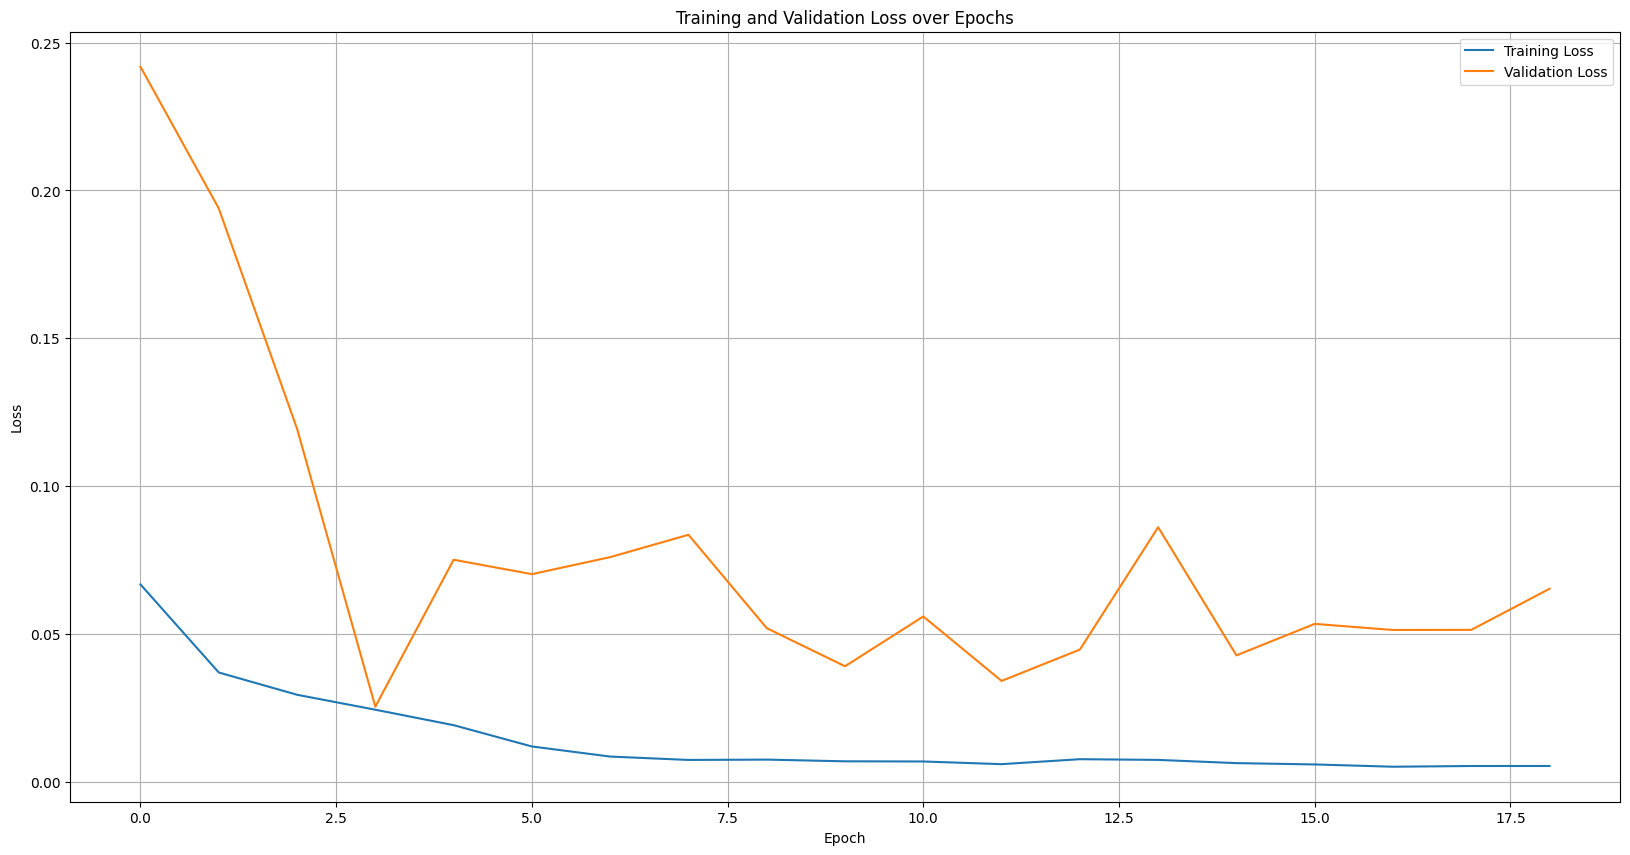

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The training history demonstrates that the model successfully found a minimum loss state within the first few epochs (around epoch 4). Subsequently, while the training loss continued to decrease or remained stable at a very low level, the validation loss began to show fluctuations and eventually started to increase slightly or plateau. This separation, where the training loss improves while the validation loss plateaus or worsens, is the classic signature of overfitting.

The Early Stopping mechanism successfully detected this plateauing performance on the validation set. By triggering termination and rolling back the model to the state corresponding to the minimum validation loss (achieved around epoch 4), the process ensured that the generalized performance was maximized, preventing the model from over-specializing in the training data and degrading its ability to forecast unseen market movements. The training ended prematurely at epoch 19, validating the effectiveness of the regularization strategy.

**Prediction Results Visualization**

**Model Mode and Prediction Flow**

Prior to generating forecasts, the PyTorch model is explicitly set to evaluation mode (model.eval()). This is a crucial step that disables layers with differing behavior during training and inference, such as Dropout and Layer Normalization, ensuring deterministic and consistent predictions.

Predictions for both the training and validation sets are collected sequentially using the non-shuffled DataLoaders. The collected data exists in the scaled, five-dimensional feature space as NumPy arrays.

**Inverse Scaling and Time Alignment**

The raw predictions and targets, which are currently standardized by the MinMaxScaler, must be reverted to their original dollar magnitude for interpretability. The inverse transformation is applied using the scaling parameters learned exclusively from the training data. This process returns the predicted and actual values for the five features (Open, Close, High, Low, Volume) to their real-world scale.

To enable time-series plotting, the forecasts must be aligned with their corresponding original day numbers. Time indices for the training set start after the sequence length (the look-back window), and the validation indices begin immediately following the end of the training data, establishing a continuous chronological timeline for visualization. The Open Price (feature 0) is then isolated as the primary target for visualization.

**Root Mean Squared Error (RMSE)**

The RMSE metric provides a quantified measure of the average error magnitude in the original units (dollars). It is calculated by taking the square root of the mean squared difference between the actual and predicted Open Prices. This metric is sensitive to large prediction errors and provides an immediately understandable measure of the model's physical deviation from the true price.

**Directional Accuracy**

Directional Accuracy is a specialized metric for financial forecasting that assesses the model's ability to correctly predict the sign of the price change (e.g., whether the closing price is greater than the opening price). Calculated by comparing the signs of the actual price difference to the predicted price difference, this metric is a critical indicator of the model's utility for market decision-making, as it is often more important to correctly predict the direction of movement than the exact magnitude.


--- Generating Predictions for Plotting ---
Train pred: (1114, 5), actual: (1114, 5)
Valid pred: (278, 5), actual: (278, 5)


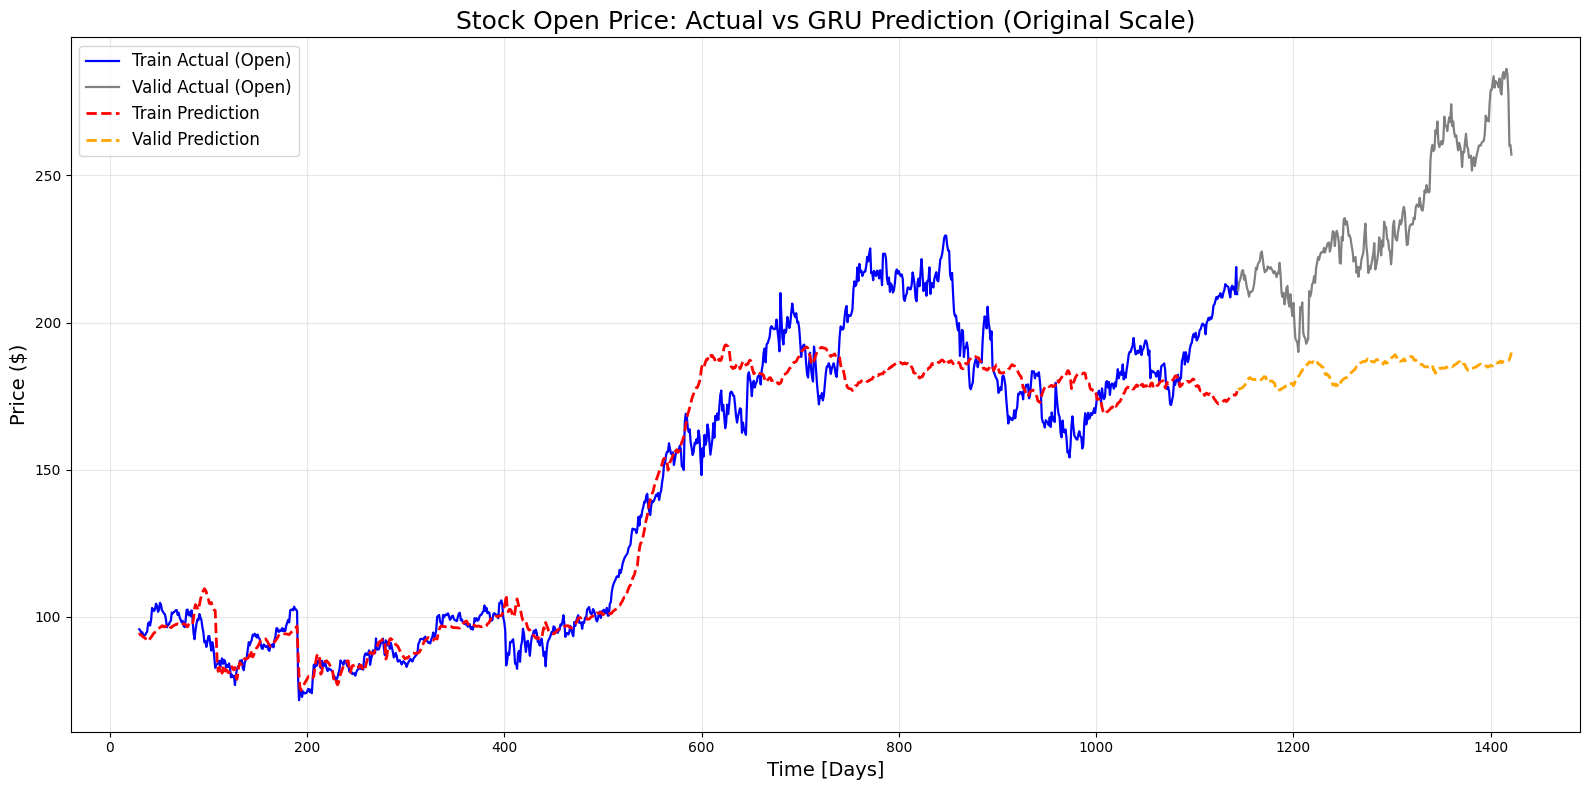

In [ ]:
model.eval()

print("\n--- Generating Predictions for Plotting ---")

def get_predictions(loader):
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    return np.vstack(preds), np.vstack(actuals)

y_train_pred_np, y_train_actual_np = get_predictions(train_loader_plot)
y_valid_pred_np, y_valid_actual_np = get_predictions(val_loader_plot)

print(f"Train pred: {y_train_pred_np.shape}, actual: {y_train_actual_np.shape}")
print(f"Valid pred: {y_valid_pred_np.shape}, actual: {y_valid_actual_np.shape}")
print("="*50)

y_train_pred_orig = scaler.inverse_transform(y_train_pred_np)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred_np)
y_train_actual_orig = scaler.inverse_transform(y_train_actual_np)
y_valid_actual_orig = scaler.inverse_transform(y_valid_actual_np)

train_start = seq_len
valid_start = seq_len + len(y_train_actual_orig)

time_train = np.arange(train_start, train_start + len(y_train_actual_orig))
time_valid = np.arange(valid_start, valid_start + len(y_valid_actual_orig))

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open   = y_train_pred_orig[:, ft]
valid_pred_open   = y_valid_pred_orig[:, ft]

plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue',   label='Train Actual (Open)',  linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray',   label='Valid Actual (Open)',  linewidth=1.6)
plt.plot(time_train, train_pred_open,   color='red',    label='Train Prediction',     linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open,   color='orange', label='Valid Prediction',     linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Visualization Interpretation**

The Stock Open Price: Actual vs Prediction plot visually confirms the metric findings. In the Training segment (blue solid line for actual, red dashed line for prediction), the red prediction line closely tracks the actual price movement, reinforcing the low training RMSE.

In the Validation segment (gray solid line for actual, orange dashed line for prediction), the orange prediction line shows a notable delay and smoothing compared to the actual gray line. While the model generally follows the trend and is in-phase with the long-term price direction, it often underestimates the magnitude of large price swings and lags in reacting to market turning points. The visual deviation of the orange dashed line from the gray solid line, especially during periods of high volatility, is the source of the much higher Valid RMSE, demonstrating the model’s limited generalization ability on new data.

**Quantitative Metrics**

In [ ]:
train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'Valid RMSE: {valid_rmse:,.2f}')

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0] 
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")
print("="*50)

Train RMSE: 14.91
Valid RMSE: 55.53

Direction Accuracy (Close > Open):
  Train: 0.533 (53.3%)
  Valid: 0.507 (50.7%)


**Quantitative Metrics**

The Train RMSE of $14.91$ suggests the model fits the historical training data well, indicating low error magnitude on the data it was explicitly trained on. However, the Valid RMSE of $55.53$ is significantly higher. This gap between the training and validation error is a clear indicator of overfitting. The model has learned patterns specific to the training set that do not generalize effectively to the unseen validation data.

The Direction Accuracy hovers near 50% for both the training (53.3%) and validation (50.7%) sets. Since 50% accuracy is equivalent to randomly guessing whether the price will go up or down, this metric indicates that the model has no significant predictive power regarding the direction of the price movement.

# Model Evaluation

**Evaluate Metrics for Regression**

This stage of the pipeline focuses on the terminal assessment of the trained LSTM model using the completely unseen test dataset, which is chronologically the furthest data segment from the training period.

**Evaluation Methodology**

The evaluation process confirms the model's performance on new data and quantifies its predictive capability using both regression and directional metrics.
- Test Loss Calculation: The model, placed in evaluation mode, computes the Mean Squared Error (MSE) loss over the entire test set. The MSE provides a baseline measurement of the prediction error within the scaled, normalized space.
- Prediction Generation: Predictions for the training, validation, and test sets are generated sequentially using their respective non-shuffled DataLoaders. This is necessary to maintain the correct chronological order required for plotting.
- Inverse Transformation: All predictions and actual targets are subjected to the inverse transform using the original MinMaxScaler parameters. This process scales the output back into the original dollar units, making the resulting metrics and visualizations interpretable in a real-world context.
- Time Alignment: Chronological time indices are calculated to align the predictions with the appropriate day in the overall time series, facilitating the continuous plotting of historical and forecasted data.

**Performance Metrics:**

- Root Mean Squared Error (RMSE): Calculated on the inverse-scaled Open Price, RMSE measures the average magnitude of the forecast error in dollars.
- Directional Accuracy (Sign Accuracy): This metric assesses the model's ability to correctly predict the sign of the daily price change (i.e., whether the Close price is higher or lower than the Open price). This is a critical indicator of the model's utility for practical financial decision-making.

In [ ]:
print("\n--- Final Test Evaluation ---")
model.eval()
test_loss_total = 0.0
with torch.no_grad():
    for x_batch, y_batch in test_loader: 
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        test_loss_total += loss.item()
final_test_loss = test_loss_total / len(test_loader)
print(f"Final Test Loss (MSE): {final_test_loss:.6f}")
print("\n--- Model Ready for Inference ---")
print("="*60)


--- Final Test Evaluation ---
Final Test Loss (MSE): 0.369556

--- Model Ready for Inference ---


**Prediction Results Visualization**


--- Generating Predictions for Plotting ---
Train pred: (1114, 5), actual: (1114, 5)
Valid pred: (278, 5), actual: (278, 5)
Test  pred: (310, 5),  actual: (310, 5)


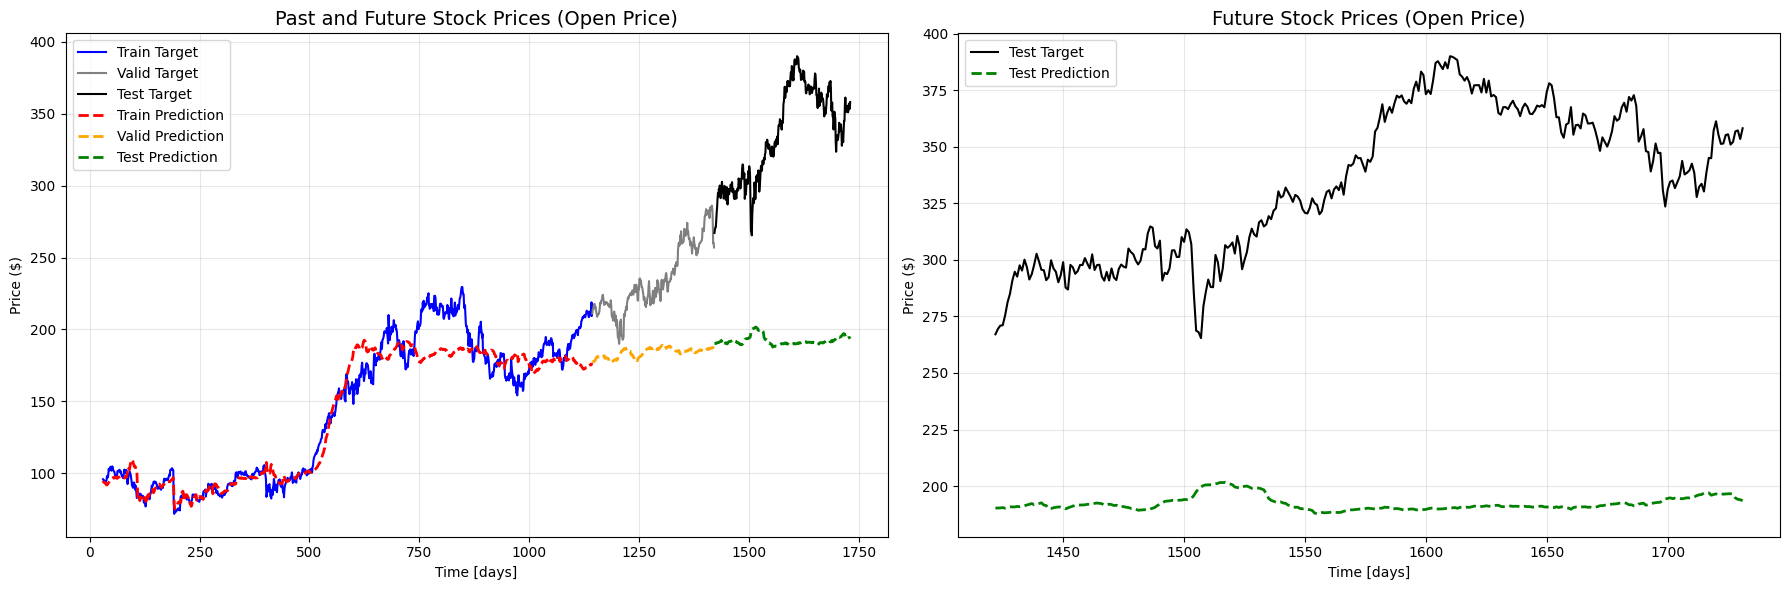

In [ ]:
print("\n--- Generating Predictions for Plotting ---")
model.eval()

def get_predictions(loader):
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    return np.vstack(preds), np.vstack(actuals)

y_train_pred_np, y_train_actual_np = get_predictions(train_loader_plot)
y_valid_pred_np, y_valid_actual_np = get_predictions(val_loader_plot)
y_test_pred_np,  y_test_actual_np  = get_predictions(test_loader_plot)

print(f"Train pred: {y_train_pred_np.shape}, actual: {y_train_actual_np.shape}")
print(f"Valid pred: {y_valid_pred_np.shape}, actual: {y_valid_actual_np.shape}")
print(f"Test  pred: {y_test_pred_np.shape},  actual: {y_test_actual_np.shape}")
print("="*60)

y_train_pred_orig = scaler.inverse_transform(y_train_pred_np)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred_np)
y_test_pred_orig  = scaler.inverse_transform(y_test_pred_np)

y_train_actual_orig = scaler.inverse_transform(y_train_actual_np)
y_valid_actual_orig = scaler.inverse_transform(y_valid_actual_np)
y_test_actual_orig  = scaler.inverse_transform(y_test_actual_np)

day_start = seq_len

n_train = len(y_train_actual_orig)
n_valid = len(y_valid_actual_orig)
n_test  = len(y_test_actual_orig)

time_train = np.arange(day_start, day_start + n_train)
time_valid = np.arange(day_start + n_train, day_start + n_train + n_valid)
time_test  = np.arange(day_start + n_train + n_valid, day_start + n_train + n_valid + n_test)

ft = 0  
plt.figure(figsize=(18, 6))

# LEFT: Full History
ax1 = plt.subplot(1, 2, 1)
ax1.plot(time_train, y_train_actual_orig[:, ft], color='blue',   label='Train Target')
ax1.plot(time_valid, y_valid_actual_orig[:, ft], color='gray',   label='Valid Target')
ax1.plot(time_test,  y_test_actual_orig[:,  ft], color='black',  label='Test Target')

ax1.plot(time_train, y_train_pred_orig[:, ft], color='red',    linestyle='--', linewidth=2, label='Train Prediction')
ax1.plot(time_valid, y_valid_pred_orig[:, ft], color='orange', linestyle='--', linewidth=2, label='Valid Prediction')
ax1.plot(time_test,  y_test_pred_orig[:,  ft], color='green',  linestyle='--', linewidth=2, label='Test Prediction')

ax1.set_title('Past and Future Stock Prices (Open Price)', fontsize=14)
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# RIGHT: Test Zoom
ax2 = plt.subplot(1, 2, 2)
ax2.plot(time_test, y_test_actual_orig[:, ft], color='black', label='Test Target')
ax2.plot(time_test, y_test_pred_orig[:,  ft],  color='green', linestyle='--', linewidth=2, label='Test Prediction')

ax2.set_title('Future Stock Prices (Open Price)', fontsize=14)
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Visualization Interpretation**

The prediction plots, consisting of the full history and a zoomed test view, visually reinforce the metric conclusions.

The left-side plot, showing the Full History, demonstrates that the predicted price (green dashed line for the test set) diverges substantially from the actual target (black solid line) during the test period. The model fails to capture the overall downward trend in the final segment, instead predicting a relatively flat or slightly delayed continuation of the previous trends.

The right-side plot, a Zoom on the Test Set, highlights this failure. The model's forecasts (green dashed line) appear highly smoothed and sluggish, consistently failing to match the volatility and sharp directional changes present in the actual stock price (black solid line). The large vertical distance between the actual and predicted curves confirms the extremely high Test RMSE of $145.71. The model, in this final evaluation, effectively performs poorly, suggesting the need for more complex architectures or the incorporation of additional, highly predictive features.

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

train_rmse = rmse(y_train_actual_orig[:, ft], y_train_pred_orig[:, ft])
valid_rmse = rmse(y_valid_actual_orig[:, ft], y_valid_pred_orig[:, ft])
test_rmse  = rmse(y_test_actual_orig[:,  ft], y_test_pred_orig[:,  ft])

print("\nRMSE (Open Price):")
print(f"  Train: {train_rmse:,.2f}")
print(f"  Valid: {valid_rmse:,.2f}")
print(f"  Test:  {test_rmse:,.2f}")

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0] 
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)
test_sign  = sign_accuracy(y_test_actual_orig,  y_test_pred_orig)

print("\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:5.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:5.1f}%)")
print(f"  Test:  {test_sign:.3f}  ({test_sign*100:5.1f}%)")
print("="*60)


RMSE (Open Price):
  Train: 14.91
  Valid: 55.53
  Test:  145.71

Direction Accuracy (Close > Open):
  Train: 0.533 ( 53.3%)
  Valid: 0.507 ( 50.7%)
  Test:  0.445  ( 44.5%)


**Results Interpretation**

The final metrics and the visualization plots reveal a significant breakdown in the model's generalization performance on the test set.

The RMSE values show a clear and severe trend of overfitting and subsequent generalization failure. The error is low on the training data ($14.91$) but increases dramatically on the validation set ($55.53$), a gap indicative of overfitting. Critically, the error explodes to $145.71$ on the final, chronologically future test set. This massive deviation signifies that the model's learned patterns are highly specific to the historical data structure and fail catastrophically when applied to the most recent, unseen market conditions.

The Directional Accuracy metrics confirm the model's lack of predictive skill regarding daily movement. The accuracy on the test set, $44.5%$, is worse than random chance ($50%$), demonstrating that the LSTM is unable to reliably forecast the price direction.

# Conclusion

This project establishes a rigorous, production-ready framework for time series forecasting using an LSTM in PyTorch. The emphasis on proper data handling—specifically chronological splitting and strict feature scaling—combined with a robust training architecture provides a strong foundation. The dual-metric evaluation strategy, combining regression error (RMSE) with directional accuracy, offers a comprehensive assessment of the model's forecasting ability on volatile financial data. This framework is easily adaptable for future enhancements, such as integrating advanced attention mechanisms or external economic features.

# References

- [Long short-term memory research paper](https://www.bioinf.jku.at/publications/older/2604.pdf)
- [Long short-term memory wikipedia](https://en.wikipedia.org/wiki/Long_short-term_memory)
- [What is LSTM - Long Short Term Memory?](https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/)
- [What is LSTM? Introduction to Long Short-Term Memory](https://www.analyticsvidhya.com/blog/2021/03/introduction-to-long-short-term-memory-lstm/)
- [Long Short Term Memory (LSTM) Networks using PyTorch](https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-networks-using-pytorch/)
- [LSTM PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html)